# EIA Data Scrape
On January 17th Watts Bar Nuclear Plant near Spring City, Tennessee had an unexpected outage. We are going to collect data from the EIA's API to understand how TVA responded. We will collect data on nuclear plant outages and electricity generation by fuel type.

First sign up for an EIA API Key [here](https://www.eia.gov/opendata/). 
Then build an API query that can collect nuclear plant outages from the EIA's API [here](https://www.eia.gov/opendata/browser/nuclear-outages). 
Finally, build an API query that can collect generation by fuel type in the TVA region [here](https://www.eia.gov/opendata/browser/electricity/rto/fuel-type-data). 


In [3]:
# Import packages and build the URLs to collect the data here
import requests
import pandas as pd
API_key=
url_gen=
url_nuclear=

In [4]:
# Call the URLs and parse the JSON responses into dataframes. I called them df_gen and df_nuclear. 


       period facility             facilityName capacity outage percentOutage  \
0  2025-03-12     7722  Watts Bar Nuclear Plant     2343   1179         50.32   
1  2025-03-11     7722  Watts Bar Nuclear Plant     2343   1179         50.32   
2  2025-03-10     7722  Watts Bar Nuclear Plant     2343   1179         50.32   
3  2025-03-09     7722  Watts Bar Nuclear Plant     2343   1179         50.32   
4  2025-03-08     7722  Watts Bar Nuclear Plant     2343   1179         50.32   

  capacity-units outage-units percentOutage-units  
0      megawatts    megawatts             percent  
1      megawatts    megawatts             percent  
2      megawatts    megawatts             percent  
3      megawatts    megawatts             percent  
4      megawatts    megawatts             percent  
          period respondent             respondent-name fueltype    type-name  \
0  2025-01-18T00        TVA  Tennessee Valley Authority      COL         Coal   
1  2025-01-18T00        TVA  Tennessee 

## Data cleaning

Now we need to clean up and combine the raw data. Some of this we have not seend before, so I have given you the code. The first problem is that the generation data comes back with each fuel type in a separate row. This is called long format and it is the way databases store data. We need to break this out into wide format to combine with the other nuclear outage data. To do this we will use a pandas command called pivot_table. For this to work you will have used the names df_nuclear and df_gen when you parsed the JSON in the cell above. 

The other issue is that pandas does not work well with dates, unless you tell it your variable is a date, not a string. The code below takes the period variable from the EIA and splits it into date and time. It then tells pandas those variables are dates/times. 

You will need to code the merge yourself. Make sure to look carefully at the column names in both dataframes before you merge. 


In [10]:
# Pivot the dataframe
df_gen_wide = df_gen.pivot_table(index='period', columns='fueltype', values='value')
df_gen_wide = df_gen_wide.reset_index()

# Extract date and time from period in generation data
df_gen_wide['datetime'] = pd.to_datetime(df_gen_wide['period'])
df_gen_wide['date'] = df_gen_wide['datetime'].dt.date
df_gen_wide['time'] = df_gen_wide['datetime'].dt.time

# Convert period to datetime in nuclear data for merging
df_nuclear['datetime'] = pd.to_datetime(df_nuclear['period'])
df_nuclear['date'] = df_nuclear['datetime'].dt.date

# Combine dataframes on date
<<YOUR CODE HERE>>

# Print the first few rows of the combined dataframe
#print(combined_df.head())

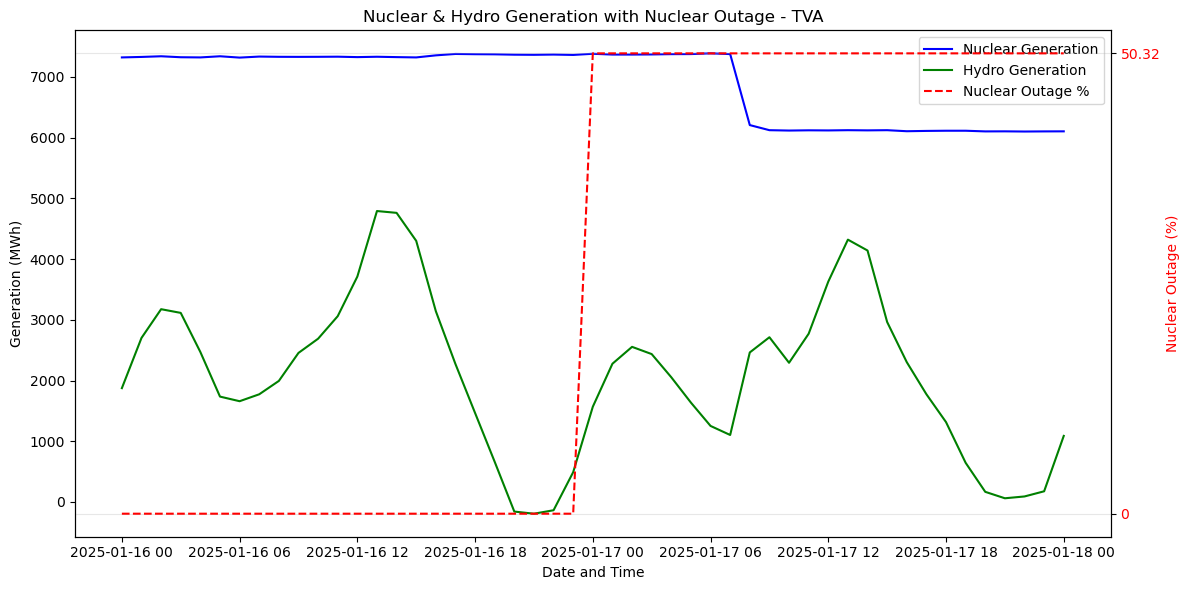

In [11]:
# Finally graph hourly generation by fuel type and nuclear plant outages. See if you can identify the short and long run response that TVA had to the nuclear outage visually. 